In [1]:
import pandas as pd
from powerball_ticket_generator import TemperatureLotteryGenerator
from powerball_backtester import PowerballBacktester
from jackpots_scraper import Jackpots

In [2]:
# Update Jackpots dataset
Jackpots().to_csv("jackpots.csv")

'jackpots.csv'

In [3]:
generator = TemperatureLotteryGenerator(
    csv_path="powerball.csv",
    T_white_min=0.0,
    T_red_min=0.0,
    temperature_scale=200.0,          # makes 200 map to alpha≈1
    temperature_sampling="rev_log1p", # mostly high T, few low T
)

tix = generator.generate_ticket_batch(
    n=5,
    max_T=200,
    include_metadata=False
)

tix = pd.DataFrame(tix)
tix

,white_1,white_2,white_3,white_4,white_5,red_ball
0,3,27,33,34,36,5
1,7,10,15,38,51,13
2,23,24,45,53,55,14
3,3,5,12,15,22,7
4,25,26,44,52,58,1



### 1) Baseline single-run backtest (fixed spend, multiplier on, temperatures stored)

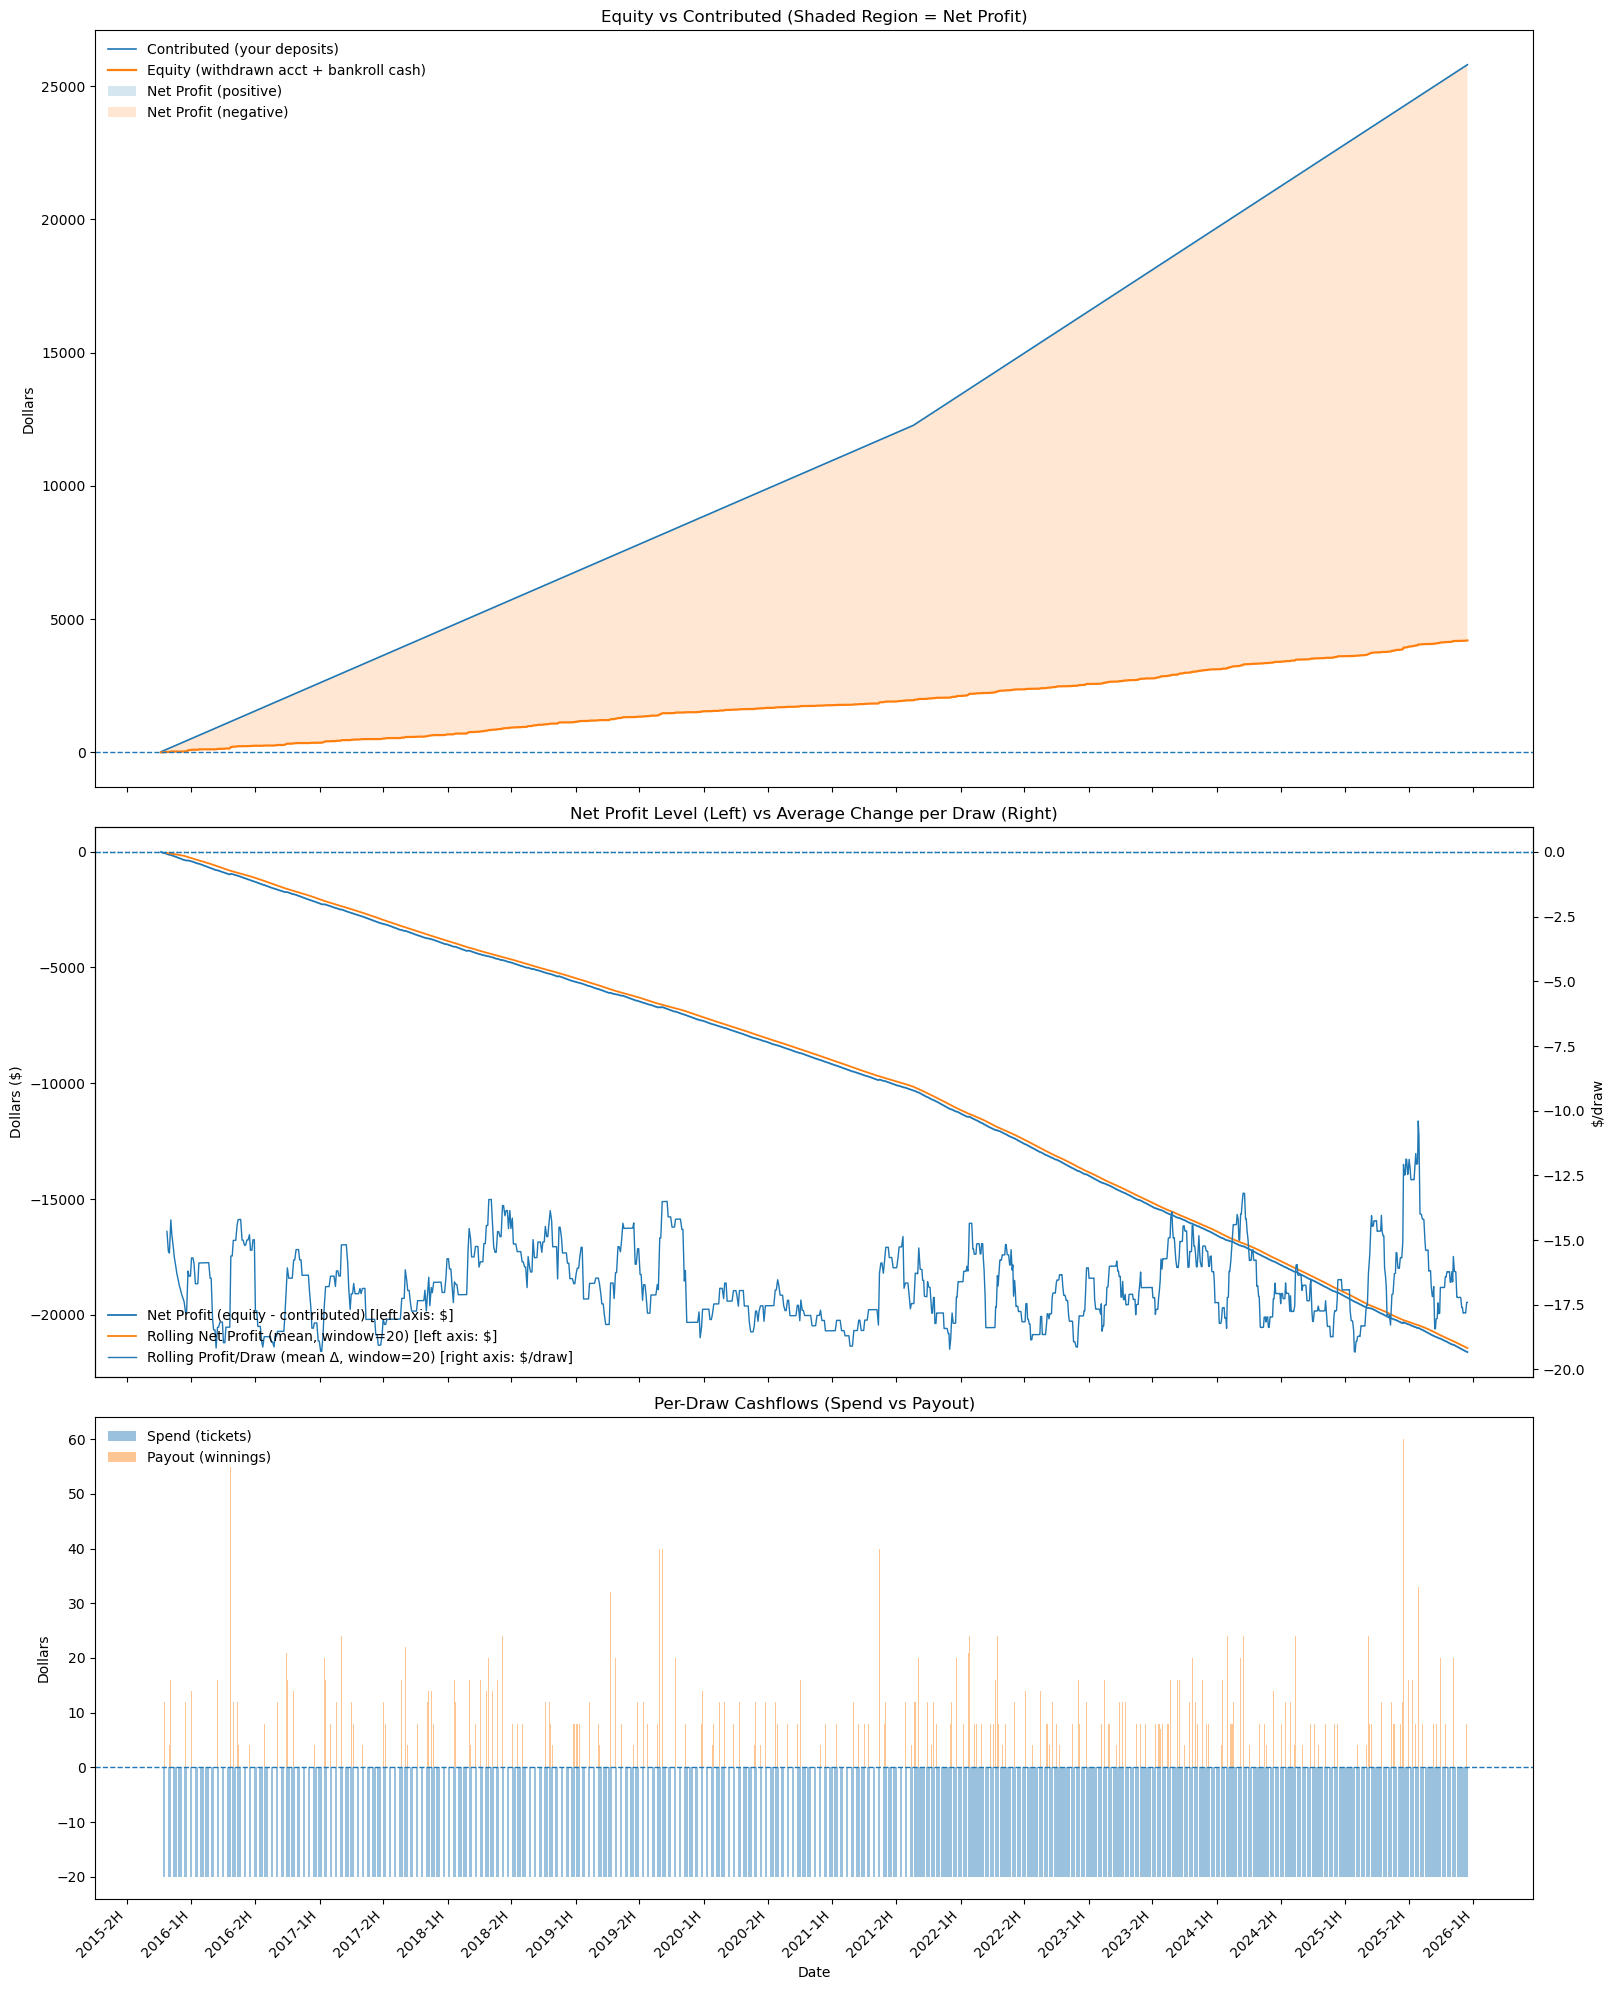

In [4]:
gen = TemperatureLotteryGenerator(
    csv_path="powerball.csv",
    T_white_min=0.0,
    T_red_min=0.0,
    temperature_scale=200.0,          # makes 200 map to alpha≈1
    temperature_sampling="rev_log1p", # mostly high T, few low T
)

bt = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=20,
    use_multiplier=True,
    reinvest_percent=0.0,
    store_temperatures=True,
    rolling_window=20,
    prefer_numba=True,
    withdrawal_apy=0.03,
    max_T=100
)

out = bt.run(seed=None)
bt.plot_winnings(out)

In [5]:
bt.pnl_table 

,date,equity,net_profit,contributed,available,spend,draw_payout,withdrawn,withdrawn_balance,bankroll_cash
0,10/07/2015,0.000000,-20.000000,20.0,20.0,20.0,0.0,0.0,0.000000,0.0
1,10/10/2015,0.000000,-40.000000,40.0,20.0,20.0,0.0,0.0,0.000000,0.0
2,10/14/2015,0.000000,-60.000000,60.0,20.0,20.0,0.0,0.0,0.000000,0.0
3,10/17/2015,12.000000,-68.000000,80.0,20.0,20.0,12.0,12.0,12.000000,0.0
4,10/21/2015,12.003885,-87.996115,100.0,20.0,20.0,0.0,0.0,12.003885,0.0
...,...,...,...,...,...,...,...,...,...,...
1285,12/06/2025,4187.940543,-21532.059457,25720.0,20.0,20.0,0.0,0.0,4187.940543,0.0
1286,12/08/2025,4188.618438,-21551.381562,25740.0,20.0,20.0,0.0,0.0,4188.618438,0.0
1287,12/10/2025,4189.296443,-21570.703557,25760.0,20.0,20.0,0.0,0.0,4189.296443,0.0
1288,12/13/2025,4198.313655,-21581.686345,25780.0,20.0,20.0,8.0,8.0,4198.313655,0.0


### 2) Determinism/regression test harness (repeatability + RNG isolation)

In [6]:
out1 = bt.run(seed=123456)
ticket1 = bt.last_ticket_detail.copy()

out2 = bt.run(seed=123456)
ticket2 = bt.last_ticket_detail.copy()

assert out1.equals(out2)
assert ticket1.equals(ticket2)
assert out1["net_profit"].iat[-1] == out2["net_profit"].iat[-1]  # scalar compare

### 3) Compare reinvestment policies (fixed_exposure vs nested_compounding)

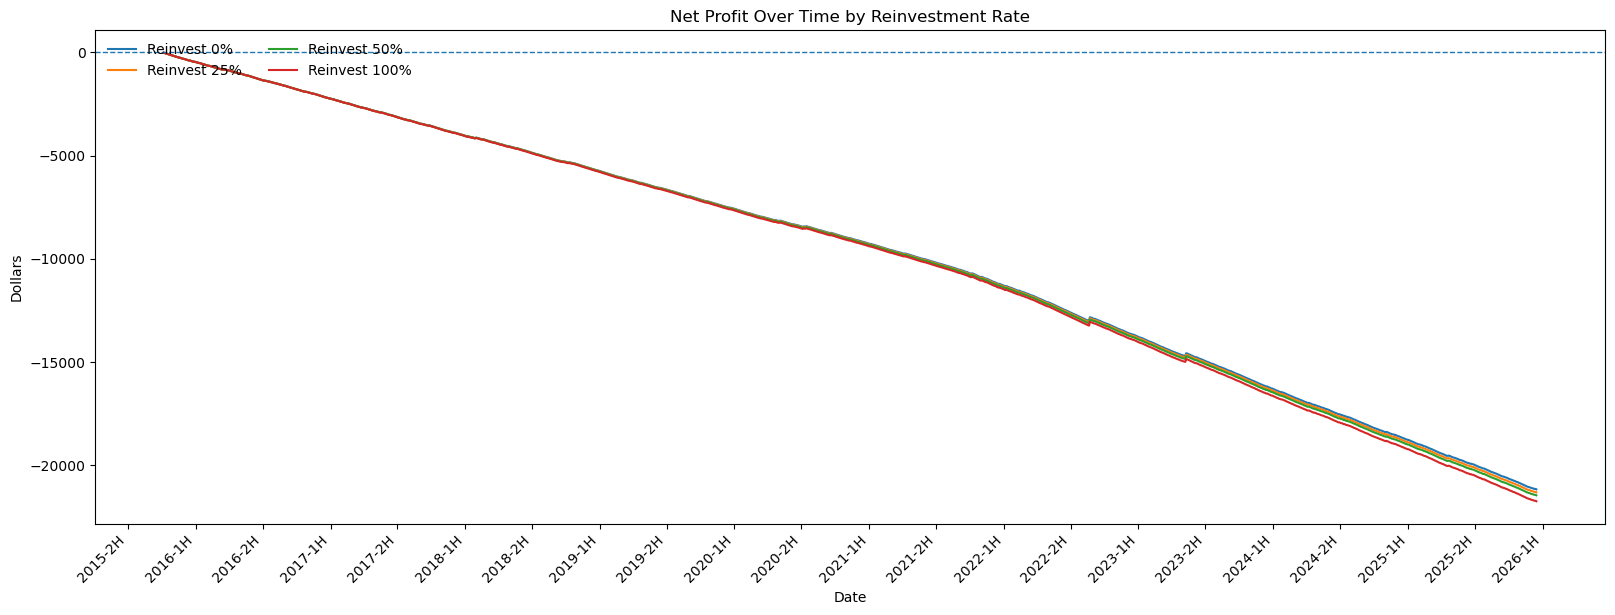

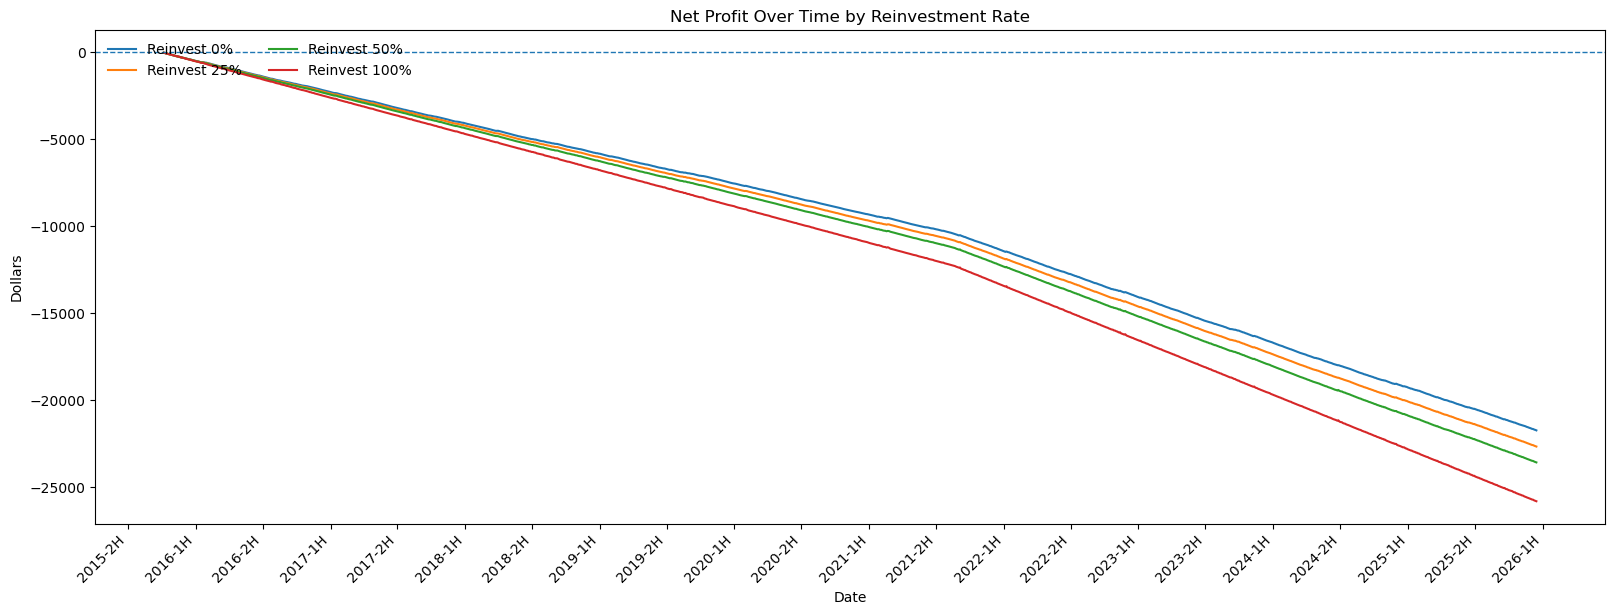

available  spend  draw_payout  draw_net  reinvested  \
reinvest_rate date                                                              
0.0           2015-10-07       20.0   20.0          0.0     -20.0         0.0   
              2015-10-10       20.0   20.0          0.0     -20.0         0.0   
              2015-10-14       20.0   20.0          0.0     -20.0         0.0   
              2015-10-17       20.0   20.0          0.0     -20.0         0.0   
              2015-10-21       20.0   20.0          0.0     -20.0         0.0   

                          withdrawn  withdrawn_balance  bankroll_cash  equity  \
reinvest_rate date                                                              
0.0           2015-10-07        0.0                0.0            0.0     0.0   
              2015-10-10        0.0                0.0            0.0     0.0   
              2015-10-14        0.0                0.0            0.0     0.0   
              2015-10-17        0.0                0.0            0.0     0.0   
              2015-10-21        0.0                0.0            0.0     0.0   

                          contributed  net_profit  rolling_pnl  \
reinvest_rate date                                               
0.0           2015-10-07         20.0       -20.0          NaN   
              2015-10-10         40.0       -40.0          NaN   
              2015-10-14         60.0       -60.0          NaN   
              2015-10-17         80.0       -80.0          NaN   
              2015-10-21        100.0      -100.0          NaN   

                          rolling_volatility  rolling_sharpe       roi  \
reinvest_rate date                                                       
0.0           2015-10-07                 NaN             NaN  0.157888   
              2015-10-10                 NaN             NaN  0.157888   
              2015-10-14                 NaN             NaN  0.157888   
              2015-10-17                 NaN             NaN  0.157888   
              2015-10-21                 NaN             NaN  0.157888   

                          net_profit_final  final_equity  \
reinvest_rate date                                         
0.0           2015-10-07     -21726.493161   4073.506839   
              2015-10-10     -21726.493161   4073.506839   
              2015-10-14     -21726.493161   4073.506839   
              2015-10-17     -21726.493161   4073.506839   
              2015-10-21     -21726.493161   4073.506839   

                          total_contributed_final  
reinvest_rate date                                 
0.0           2015-10-07                  25800.0  
              2015-10-10                  25800.0  
              2015-10-14                  25800.0  
              2015-10-17                  25800.0  
              2015-10-21                  25800.0

In [7]:
# Same ticket count each draw (isolates accounting effects)
df_fixed = bt.compare_reinvest_rates(
    reinvest_rates=(0.0, 0.25, 0.5, 1.0),
    seed=20250101,
    mode="fixed_exposure",
    plot=True,
)

# “Reinvest buys more tickets” while keeping runs comparable via nested pools
df_nested = bt.compare_reinvest_rates(
    reinvest_rates=(0.0, 0.25, 0.5, 1.0),
    seed=20250101,
    mode="nested_compounding",
    plot=True,
)

df_nested.head()

### 4) Model “withdraw winnings into an external account” (withdrawal_apy + draws_per_year)

In [8]:
bt = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=100,
    reinvest_percent=0.50,   # half reinvest, half withdraw
    withdrawal_apy=0.05,     # external compounding on withdrawals
    draws_per_year=104,      # used to convert APY to per-draw rate
    max_T=200
)

out = bt.run(seed=7)
out

,date,available,spend,draw_payout,draw_net,reinvested,withdrawn,withdrawn_balance,bankroll_cash,equity,contributed,net_profit,rolling_pnl,rolling_volatility,rolling_sharpe
0,10/07/2015,100.0,100.0,12.0,-88.0,6.0,6.0,6.000000,6.0,12.000000,100.0,-88.000000,NaN,NaN,NaN
1,10/10/2015,106.0,106.0,8.0,-98.0,4.0,4.0,10.002405,4.0,14.002405,200.0,-185.997595,NaN,NaN,NaN
2,10/14/2015,104.0,104.0,24.0,-80.0,12.0,12.0,22.007751,12.0,34.007751,300.0,-265.992249,NaN,NaN,NaN
3,10/17/2015,112.0,112.0,4.0,-108.0,2.0,2.0,24.016572,2.0,26.016572,400.0,-373.983428,NaN,NaN,NaN
4,10/21/2015,102.0,102.0,16.0,-86.0,8.0,8.0,32.029408,8.0,40.029408,500.0,-459.970592,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1285,12/06/2025,112.0,112.0,0.0,-112.0,0.0,0.0,13585.076433,0.0,13585.076433,128600.0,-115014.923567,-2776.0,19.085530,-26.555507
1286,12/08/2025,100.0,100.0,16.0,-84.0,8.0,8.0,13596.706312,8.0,13604.706312,128700.0,-115095.293688,-2801.0,18.090736,-28.268076
1287,12/10/2025,108.0,108.0,24.0,-84.0,12.0,12.0,13612.339298,12.0,13624.339298,128800.0,-115175.660702,-2755.0,16.780702,-29.974425
1288,12/13/2025,112.0,112.0,8.0,-104.0,4.0,4.0,13621.795408,4.0,13625.795408,128900.0,-115274.204592,-2775.0,16.855880,-30.057367


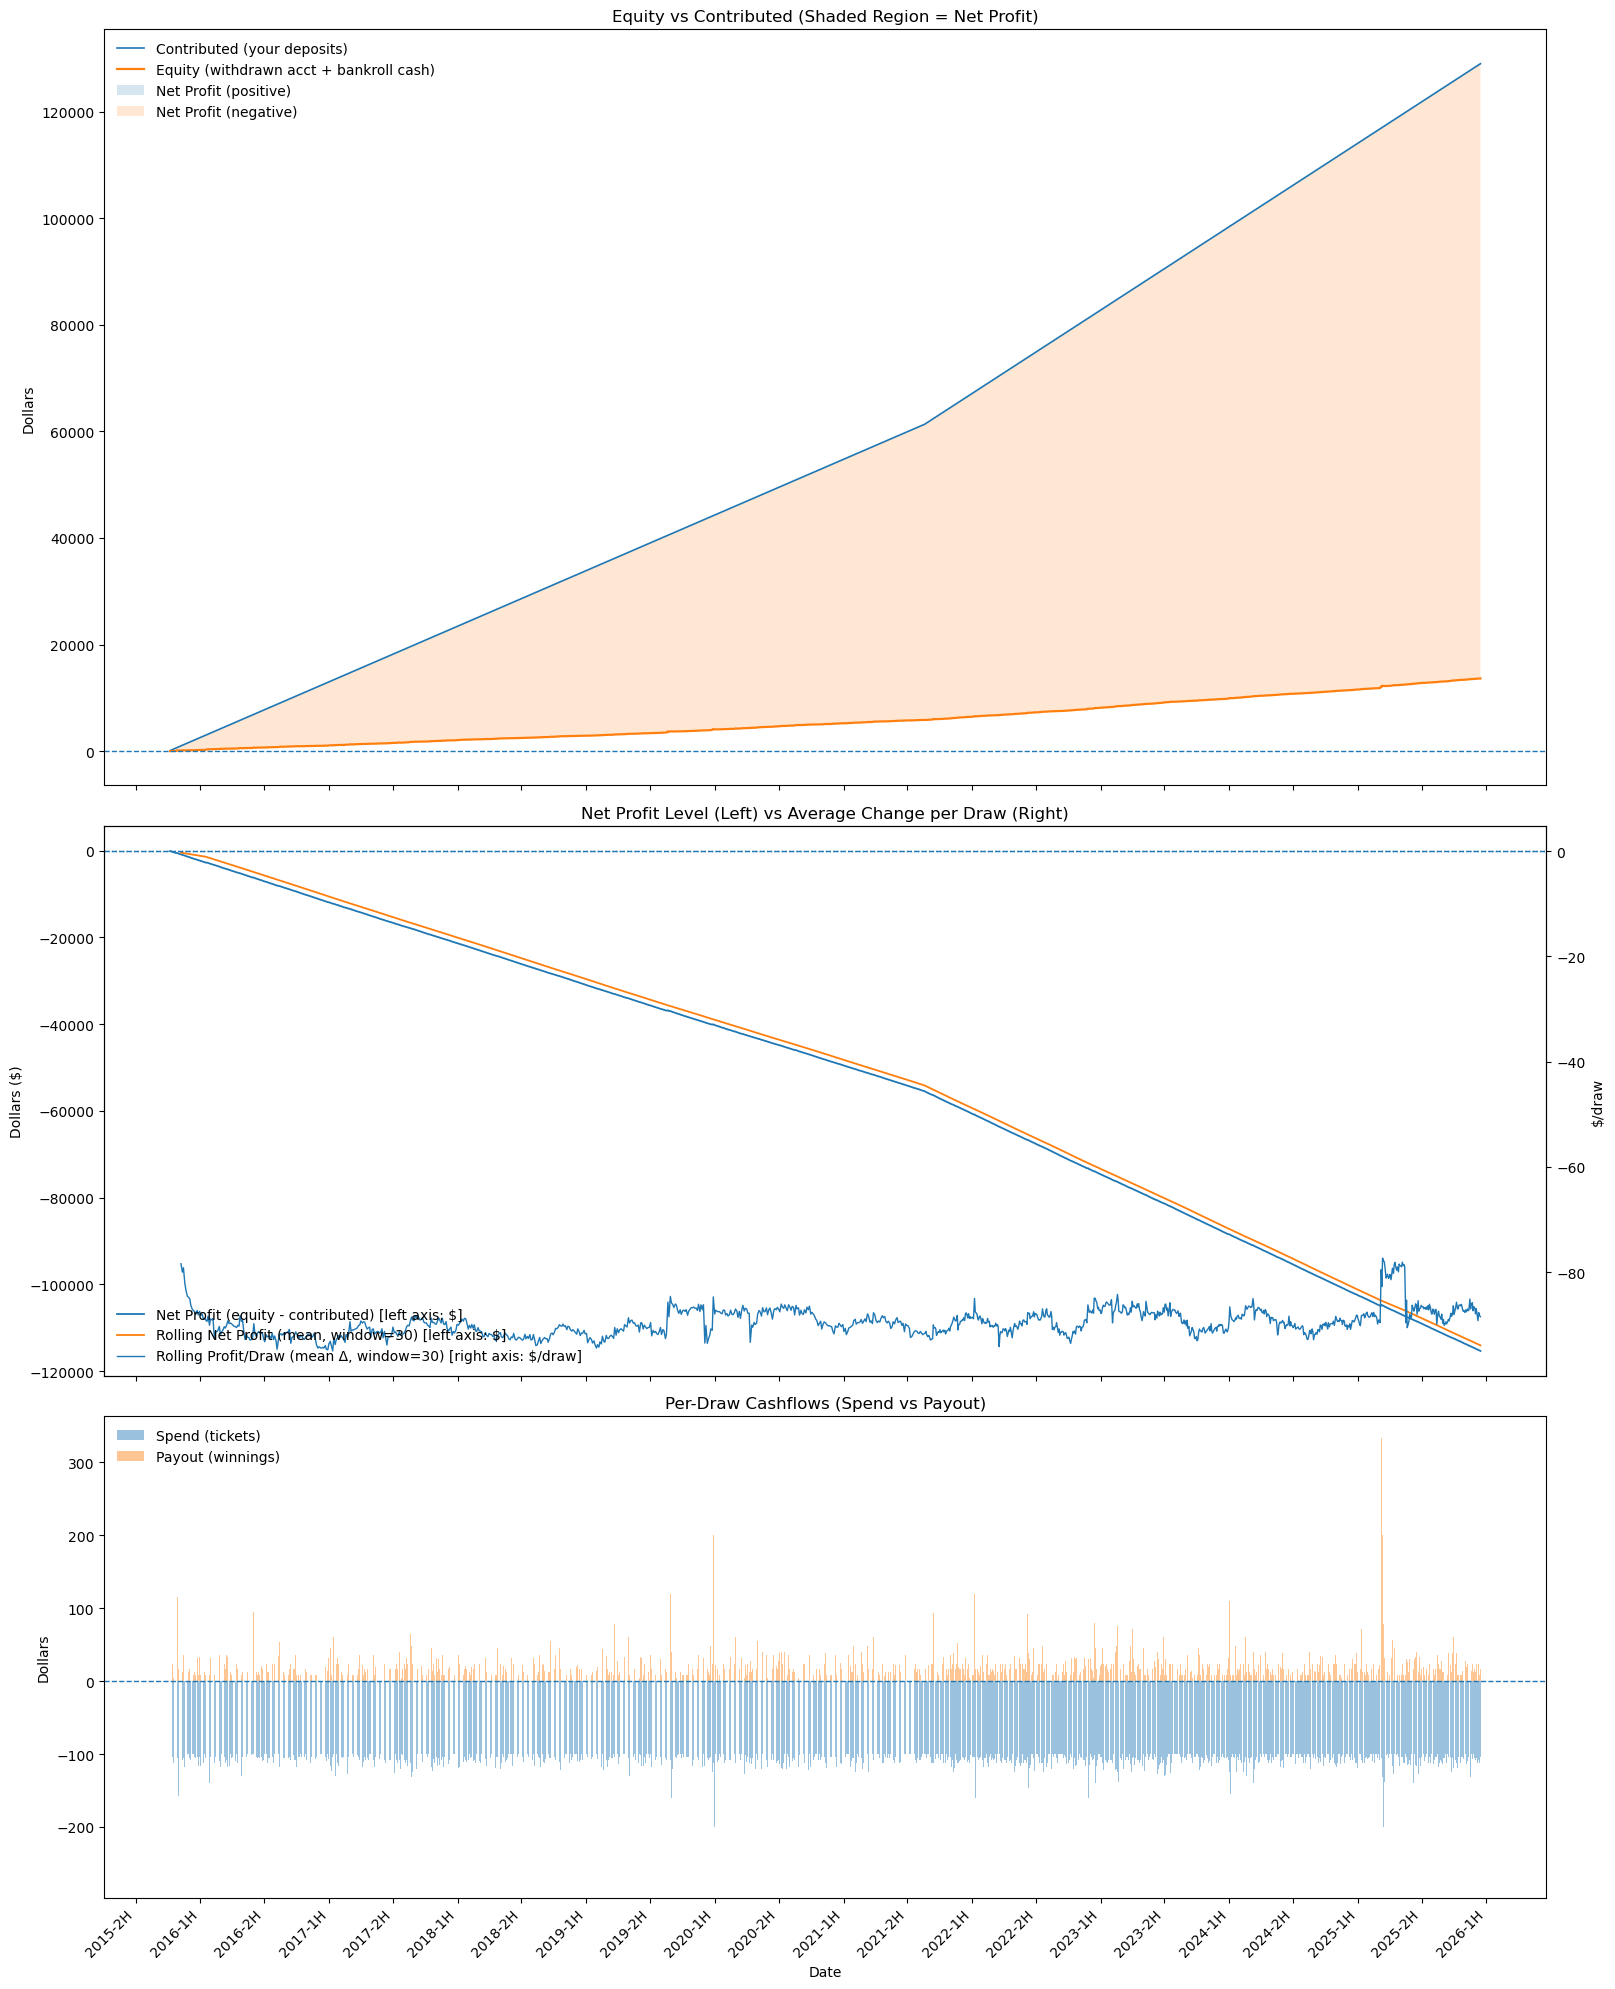

In [9]:
bt.plot_winnings(out)

### 5) Plot a single run with dual-axis “net profit level vs profit/draw” and cashflows

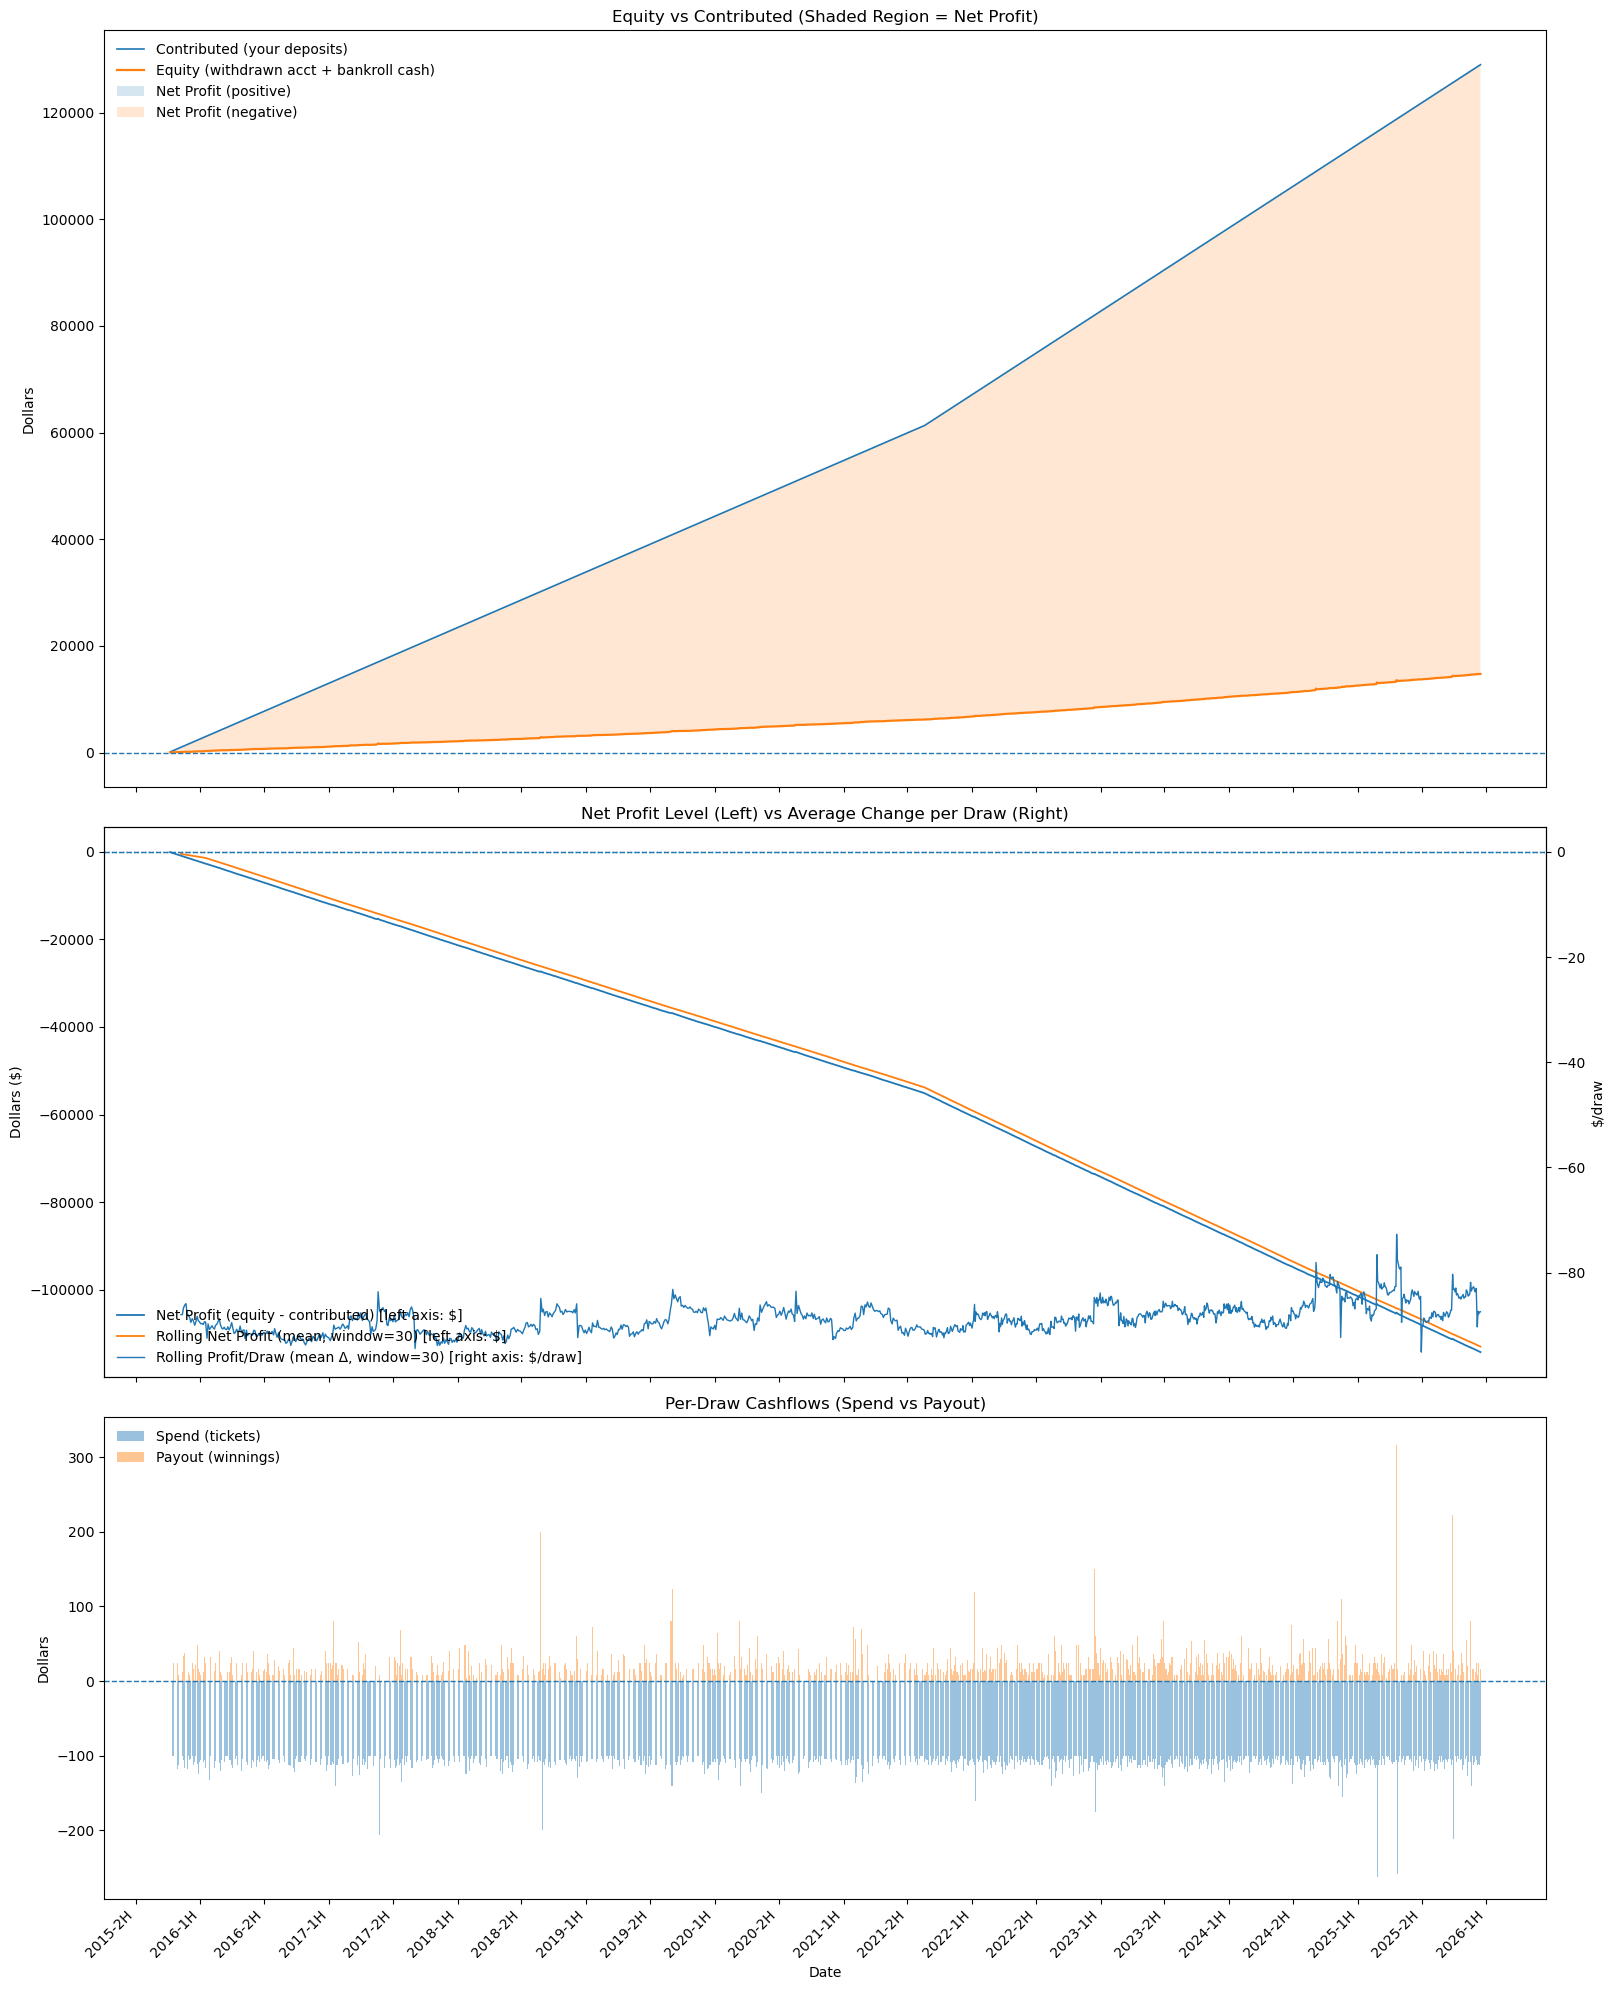

In [10]:
out = bt.run(seed=123)
bt.plot_winnings(out)
# optional:
ticket_df = bt.last_ticket_detail
summary = bt.last_summary

### 6) Temperature-stratified performance (deciles of white temperature)

In [11]:
draw_detail = bt.run(seed=123)  # run() returns draw_detail now :contentReference[oaicite:1]{index=1}
ticket_detail = bt.last_ticket_detail  # populated by run() :contentReference[oaicite:2]{index=2}

summary = bt.summarize_by_white_temperature_deciles(ticket_detail, q=10)
summary

,mean_payout,hit_rate,n
temp_bin,,,
"(0.00722, 82.798]",0.508003,0.040017,4748
"(82.798, 131.607]",0.497577,0.041500,4747
"(131.607, 159.869]",0.416263,0.039393,4747
"(159.869, 176.714]",0.512324,0.043606,4747
"(176.714, 186.755]",0.527491,0.042764,4747
"(186.755, 192.53]",0.476090,0.041500,4747
"(192.53, 196.023]",0.453128,0.042132,4747
"(196.023, 198.083]",0.546450,0.041079,4747
"(198.083, 199.289]",0.482199,0.042343,4747


### 7) Performance run: turn off metadata to reduce overhead (store_temperatures=False)

In [12]:
bt_fast = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=500,
    store_temperatures=False,  # leaner generation; no temp columns
    prefer_numba=True,
)

draw_detail = bt_fast.run(seed=123)  # returns draw_detail :contentReference[oaicite:3]{index=3}
ticket_detail = bt_fast.last_ticket_detail  # populated by run() :contentReference[oaicite:4]{index=4}

print(ticket_detail.columns)  # should not include white_temperature/red_temperature

Index(['date', 'cost', 'payout', 'multiplier', 'white_1', 'white_2', 'white_3',
       'white_4', 'white_5', 'red_ball'],
      dtype='object')


### 8) Verify multiplier economics and budget allocation behavior

In [13]:
bt_alloc = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=7,
    use_multiplier=True,
)

# Internal allocation logic: (n_multiplier, n_non_multiplier)
print(bt_alloc._allocate_ticket_counts(7))   # expected pattern like (1, 2)
print(bt_alloc._allocate_ticket_counts(10))  # expected pattern like (2, 2)

(1, 2)
(2, 2)


### 9) Enforced uniqueness across multiplier and non-multiplier pools (per draw)

In [14]:
bt = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,            # must support existing_tickets=...
    ticket_budget=101,
    use_multiplier=True,
)

draw_detail = bt.run(seed=99)          # returns draw_detail :contentReference[oaicite:5]{index=5}
td = bt.last_ticket_detail             # ticket-level rows :contentReference[oaicite:6]{index=6}

dupes = td.duplicated(
    subset=["date", "white_1", "white_2", "white_3", "white_4", "white_5", "red_ball"]
).sum()

print("duplicate tickets within a draw:", dupes)

duplicate tickets within a draw: 0


### 10) Use the generator standalone (CSV-friendly ticket export + uniqueness controls)

In [15]:
gen = TemperatureLotteryGenerator(
    csv_path="powerball.csv",
    T_white_min=0.0,
    T_red_min=0.0,
    temperature_scale=200.0,          # makes 200 map to alpha≈1
    temperature_sampling="rev_log1p", # mostly high T, few low T
)

# Cashier-friendly output (flat columns)
tickets = gen.generate_ticket_batch(
    n=10,
    max_T=50.0,
    include_metadata=False,
    ensure_unique=True,
)

# Export-ready
df = pd.DataFrame(tickets)
df.to_csv("tickets.csv", index=False)

# Enforce uniqueness vs an existing pool (e.g., “don’t repeat last week’s tickets”)
more = gen.generate_ticket_batch(
    n=10,
    max_T=50.0,
    include_metadata=True,
    ensure_unique=True,
    existing_tickets=tickets,
)

df

,white_1,white_2,white_3,white_4,white_5,red_ball
0,13,25,35,40,61,13
1,18,23,28,35,62,26
2,8,14,25,28,47,14
3,2,9,37,53,55,25
4,12,28,34,38,53,12
5,24,27,37,67,69,19
6,10,23,24,39,47,21
7,1,4,28,30,45,23
8,1,3,4,21,58,5
9,5,6,29,37,67,2


In [16]:
pd.DataFrame(more)

,white_balls,red_ball,T_white,T_red,max_T
0,"[25, 26, 31, 42, 49]",2,6.756752,16.520278,50.0
1,"[1, 6, 26, 41, 59]",2,49.628573,39.380920,50.0
2,"[5, 7, 16, 54, 68]",4,10.386096,37.312940,50.0
3,"[16, 23, 39, 46, 47]",14,22.243802,28.284854,50.0
4,"[18, 29, 40, 48, 54]",20,49.114565,4.453661,50.0
5,"[5, 25, 38, 60, 63]",3,48.107385,17.050606,50.0
6,"[3, 6, 19, 38, 61]",15,43.453715,42.634328,50.0
7,"[14, 19, 33, 61, 62]",1,47.598481,46.797926,50.0
8,"[22, 27, 29, 30, 38]",8,49.551572,49.935311,50.0
9,"[6, 21, 32, 34, 55]",12,39.197417,37.526484,50.0


In [34]:
import numpy as np
import pandas as pd

from powerball_backtester import PowerballBacktester
from powerball_ml_ticket_generator import PowerballMLTicketGenerator  # wherever you saved the class
from scipy.stats import randint, loguniform
from joblib import parallel_backend

'''
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Unit time (1 head, 1 ensemble member, full search): 281.3 seconds
Estimated total (upper bound, red ~= white): 4.22 hours
Estimated total (red ~ 0.5 * white):         3.87 hours

With mc_strategy="repeated_random_search" multipy by 33.5 for 40 n_iter
With mc_strategy="repeated_random_search" multipy by 16.8 for 20 n_iter
'''

param_space = {
    # More conservative; avoids aggressive fitting.
    "model__learning_rate": loguniform(0.02, 0.06),

    # Lower capacity; discourages memorization of lag-feature quirks.
    "model__max_leaf_nodes": randint(8, 41),          # [8..40]

    # Stronger smoothing (crucial for the red head).
    "model__min_samples_leaf": randint(10, 77),      # [40..250]

    # Push regularization up; noise-fitting becomes expensive.
    "model__l2_regularization": loguniform(1e-3, 10.0),

    # Keep trees shallow; drop None to avoid “free depth”.
    "model__max_depth": [2, 3, 4],

    # Coarser hist bins; fewer split candidates.
    "model__max_bins": randint(64, 129),              # [64..128]
}

with parallel_backend("threading"):
    ml = PowerballMLTicketGenerator(
        draw_data="powerball.csv",
        lag_n=3,
        rolling_windows=(5, 10, 15),
        augment_permutations=20,
        use_quantile=False,                 # OFF for boosting
        enable_tuning=True,
        mc_ensemble_size=5,                 # must be >= max ensemble_size you want to test later
        mc_strategy="repeated_random_search",
        tuning_n_iter=15,
        tuning_cv_splits=3,                 # TimeSeriesSplit on train only
        param_distributions=param_space,
        seed=123,
        verbose=True,
        n_jobs=4
    ).fit()

print(ml.evaluate(split="val"))

# Save without embedding draws (smaller artifact)
ml.save_state("boosted_trees_with_perm_powerball.joblib", include_draws=False)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END model__l2_regularization=1.4561067260494638, model__learning_rate=0.03453057509286371, model__max_bins=75, model__max_depth=3, model__max_leaf_nodes=21, model__min_samples_leaf=28; total time= 4.3min
[CV] END model__l2_regularization=0.5576224126371576, model__learning_rate=0.045609554275934515, model__max_bins=98, model__max_depth=3, model__max_leaf_nodes=37, model__min_samples_leaf=65; total time= 4.4min
[CV] END model__l2_regularization=1.4561067260494638, model__learning_rate=0.03453057509286371, model__max_bins=75, model__max_depth=3, model__max_leaf_nodes=21, model__min_samples_leaf=28; total time= 5.0min
[CV] END model__l2_regularization=1.4561067260494638, model__learning_rate=0.03453057509286371, model__max_bins=75, model__max_depth=3, model__max_leaf_nodes=21, model__min_samples_leaf=28; total time= 5.3min
[CV] END model__l2_regularization=9.776871203343195, model__learning_rate=0.05971046463171486, model__

In [35]:
from powerball_backtester import PowerballBacktester
from powerball_ml_ticket_generator import PowerballMLTicketGenerator  # wherever you saved the class

# Later: load and provide draw_data
ml = PowerballMLTicketGenerator.load_state(
    "boosted_trees_with_perm_powerball.joblib",
    draw_data="powerball.csv",
)

tickets = ml.generate_tickets(n=20, temperature=1.0, as_flat=True)
print(tickets[0])

{'white_1': 15, 'white_2': 19, 'white_3': 26, 'white_4': 53, 'white_5': 63, 'red_ball': 23}


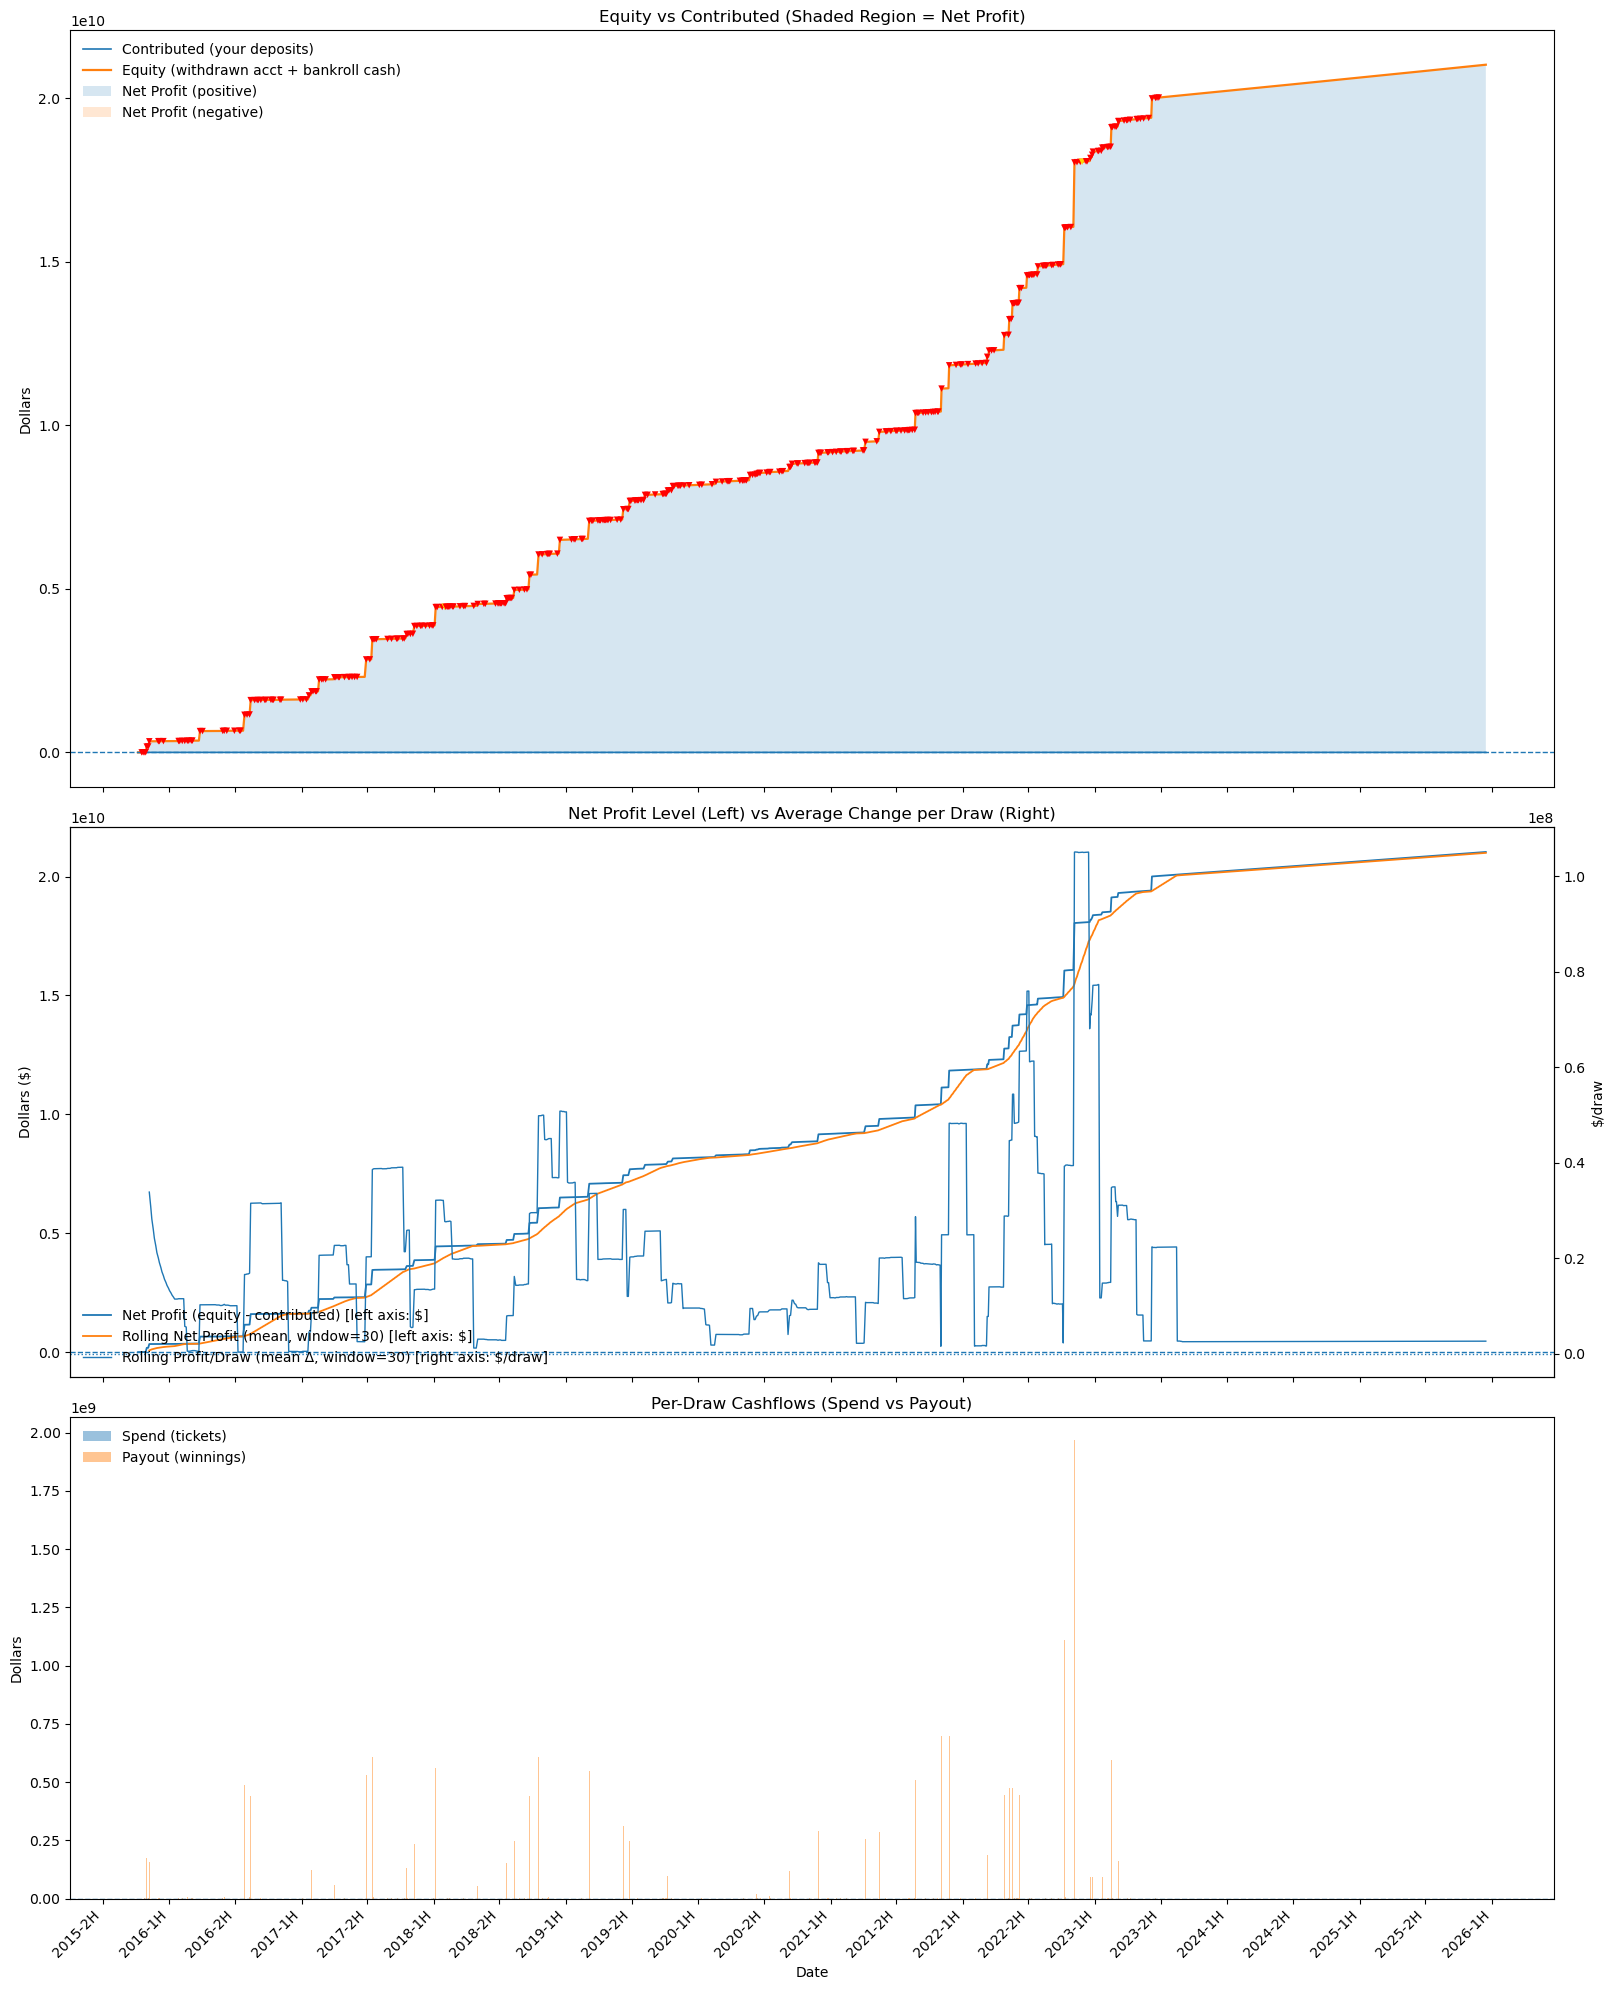

In [36]:
from powerball_ml_ticket_generator import PowerballMLTicketGenerator
from powerball_ml_policy import MLBacktesterGenerator
from powerball_backtester import PowerballBacktester

gen = MLBacktesterGenerator(
    ml=ml,
    temperature=1.0,
    ensemble_size=1,
    seed=123
)

bt = PowerballBacktester(
    draw_csv="powerball.csv",
    jackpot_csv="jackpots.csv",
    generator=gen,
    ticket_budget=3,
    use_multiplier=True,
    reinvest_percent=0.0
)
out = bt.run()
bt.plot_winnings(out)

In [37]:
bt.last_summary

{'final_equity': 21031761692.99098,
 'final_net_profit': 21031757822.99098,
 'total_contributed': 3870.0,
 'total_payout': 18868510029.146194,
 'total_spend': 3870.0,
 'roi': 5434563.744958909}

In [38]:
bt.last_ticket_detail.iloc[-100:]

,date,cost,payout,multiplier,white_1,white_2,white_3,white_4,white_5,red_ball,white_temperature,red_temperature
1190,04/28/2025,3,0.0,4,9,14,37,45,47,21,1.0,1.0
1191,04/30/2025,3,0.0,2,29,56,61,63,66,21,1.0,1.0
1192,05/03/2025,3,0.0,2,21,27,40,48,61,9,1.0,1.0
1193,05/05/2025,3,0.0,2,38,46,48,54,59,10,1.0,1.0
1194,05/07/2025,3,0.0,3,9,19,30,53,67,17,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1285,12/06/2025,3,0.0,2,3,15,32,44,64,18,1.0,1.0
1286,12/08/2025,3,0.0,2,2,20,33,64,69,10,1.0,1.0
1287,12/10/2025,3,0.0,3,16,21,33,45,62,26,1.0,1.0
1288,12/13/2025,3,0.0,2,3,28,45,47,54,8,1.0,1.0


In [39]:
n = len(ml.draws) - 1
n_test = max(1, int(round(n * ml.test_size)))
n_val  = max(1, int(round(n * ml.val_size)))
n_train = n - n_val - n_test

val_start = n_train + 1
val_end   = n_train + n_val
pnl_val = out.iloc[val_start:val_end+1]
print("VAL window net:", (pnl_val["draw_payout"] - pnl_val["spend"]).sum())
print("VAL window max draw_payout:", pnl_val["draw_payout"].max())

VAL window net: -543.0
VAL window max draw_payout: 12.0


In [40]:
out.iloc[val_start:val_end+1]

,date,available,spend,draw_payout,draw_net,reinvested,withdrawn,withdrawn_balance,bankroll_cash,equity,contributed,net_profit,rolling_pnl,rolling_volatility,rolling_sharpe
904,07/01/2023,3.0,3.0,0.0,-3.0,0.0,0.0,2.003232e+10,0.0,2.003232e+10,2715.0,2.003232e+10,5.955589e+08,1.078465e+08,1.008226
905,07/03/2023,3.0,3.0,0.0,-3.0,0.0,0.0,2.003450e+10,0.0,2.003450e+10,2718.0,2.003449e+10,5.955587e+08,1.078465e+08,1.008226
906,07/05/2023,3.0,3.0,0.0,-3.0,0.0,0.0,2.003667e+10,0.0,2.003667e+10,2721.0,2.003667e+10,5.954587e+08,1.078471e+08,1.008051
907,07/08/2023,3.0,3.0,0.0,-3.0,0.0,0.0,2.003993e+10,0.0,2.003993e+10,2724.0,2.003993e+10,5.953587e+08,1.078478e+08,1.007876
908,07/10/2023,3.0,3.0,0.0,-3.0,0.0,0.0,2.004210e+10,0.0,2.004210e+10,2727.0,2.004210e+10,5.953584e+08,1.078478e+08,1.007875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1092,09/11/2024,3.0,3.0,0.0,-3.0,0.0,0.0,2.051372e+10,0.0,2.051372e+10,3279.0,2.051372e+10,-8.200000e+01,5.321201e+00,-2.813478
1093,09/14/2024,3.0,3.0,0.0,-3.0,0.0,0.0,2.051706e+10,0.0,2.051706e+10,3282.0,2.051706e+10,-8.200000e+01,5.321201e+00,-2.813478
1094,09/16/2024,3.0,3.0,0.0,-3.0,0.0,0.0,2.051929e+10,0.0,2.051929e+10,3285.0,2.051928e+10,-8.200000e+01,5.321201e+00,-2.813478
1095,09/18/2024,3.0,3.0,0.0,-3.0,0.0,0.0,2.052151e+10,0.0,2.052151e+10,3288.0,2.052151e+10,-8.200000e+01,5.321201e+00,-2.813478


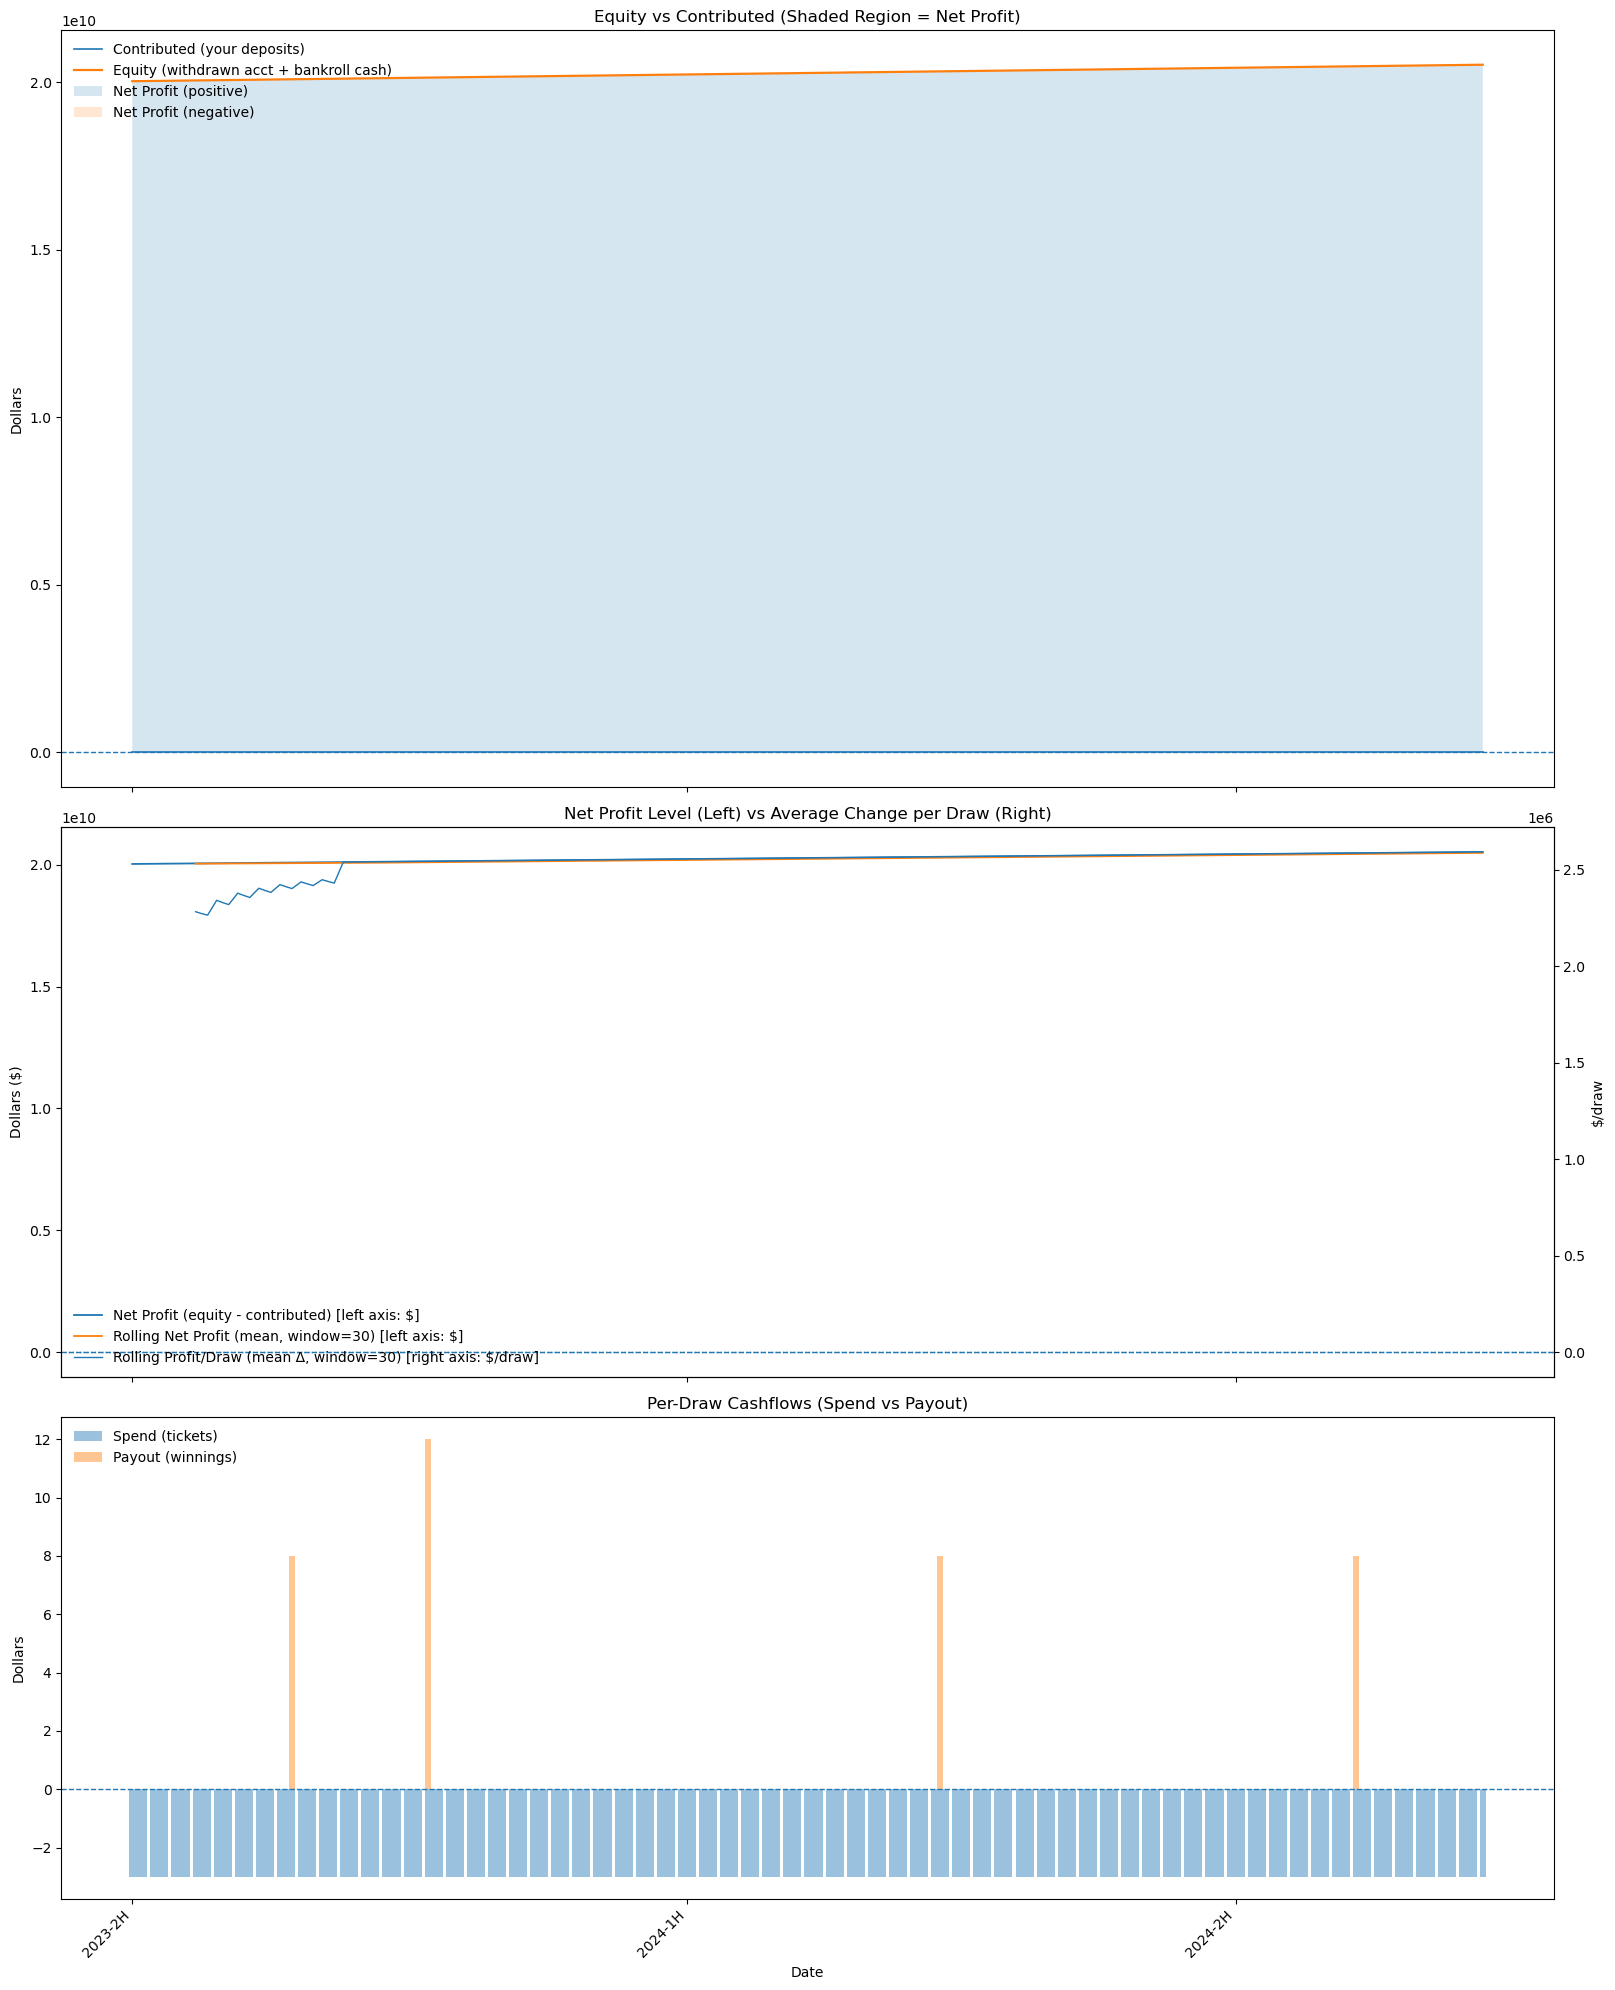

In [41]:
bt.plot_winnings(pnl_val)

In [42]:
# from powerball_ml_policy import policy_search_on_val, MLBacktesterGenerator
# from powerball_backtester import PowerballBacktester

# # 1) pick policy on val
# best_policy, policy_df = policy_search_on_val(
#     ml,
#     draw_csv="powerball.csv",
#     jackpot_csv="jackpots.csv",
#     ticket_budget=20,
#     use_multiplier=False,
# )

# T_star = float(best_policy["temperature"])
# M_star = int(best_policy["ensemble_size"])

# # 2) run backtest using chosen policy
# gen_star = MLBacktesterGenerator(ml, temperature=T_star, ensemble_size=M_star, seed=123)

# bt = PowerballBacktester(
#     draw_csv="powerball.csv",
#     jackpot_csv="jackpots.csv",
#     generator=gen_star,
#     ticket_budget=20,
#     use_multiplier=False,
#     reinvest_percent=0.0,
#     store_temperatures=True,
#     seed=123,
# )

# pnl = bt.run(seed=123)  # run() returns a draw-level DataFrame and sets bt.last_ticket_detail :contentReference[oaicite:3]{index=3}
# ticket_detail = bt.last_ticket_detail

# print(pnl.tail())
# print("Final net_profit:", float(pnl["net_profit"].iloc[-1]))
# print("Ticket rows:", ticket_detail.shape)

# # 3) TEST-window incremental profit
# n_train = len(ml.splits_.X_train)
# n_val = len(ml.splits_.X_val)
# n_test = len(ml.splits_.X_test)

# test_start = (n_train + n_val) + 1
# test_end = (n_train + n_val + n_test)

# pnl_test = pnl.iloc[test_start:test_end + 1]
# test_profit = float((pnl_test["draw_payout"] - pnl_test["spend"]).sum())
# print("Incremental profit over TEST window:", test_profit)